# Encoder Simulation & Inference

Uses encoder outputs to study latent space structure and synthesize user preferences.

> Generated from `Lab2_multi_task_modal.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import ast
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import tensorflow as tf
import tensorflow.keras
import keras
from tensorflow.keras import layers
from keras.models import Sequential
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import plotly.io as plt_io
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import itertools
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
import random
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve, auc, classification_report
%matplotlib inline

### Creating List of Genres for each Activity

In [17]:
# a list of genre groups for exercising
exercise_genres = ['pop', 'rock', 'hip_hop', 'metal', 'rap', 'edm', 'electronic', 'house', 'punk']
# a list of genre groups for relaxing
relax_genres = ['r&b', 'adult_standards', 'soul', 'reggae', 'classical', 'jazz', 'ambient']
# a list of genre groups for commmuting
commute_genres = ['pop', 'rock', 'country', 'hip_hop', 'funk', 'latin', 'disco', 'folk', 'rap']

### Calculating Genre Centroids

In [18]:
#a function that finds the centroid of a genre group in the latent space
def find_centroid(genre_group):
    #get the index of each song in the genre group
    genre_group_index = np.where(y_train_embedding == genre_group)[0]
    #get the latent space of the genre group
    #print(genre_group_index.shape)
    genre_group_latent_space = latent_space[genre_group_index, :]
    #find the centroid of the genre group
    centroid = np.mean(genre_group_latent_space, axis=0)
    #find the standard deviation of the genre group
    std = np.std(genre_group_latent_space, axis=0)
    #return the centroid and standard deviation
    return centroid, std

#find the centroid of each genre groups above and store them in a dictionary
exercise_centroids = np.array([find_centroid(genre) for genre in exercise_genres])
relax_centroids = np.array([find_centroid(genre) for genre in relax_genres])
commute_centroids = np.array([find_centroid(genre) for genre in commute_genres])

#combine the centroids into a single array with their original lists as labels
centroids = np.concatenate((exercise_centroids, relax_centroids, commute_centroids), axis=0)
activity_labels = ['exercise'] * len(exercise_centroids) + ['relax'] * len(relax_centroids) + ['commute'] * len(commute_centroids)
genre_group_labels = exercise_genres + relax_genres + commute_genres
centroids.shape



(25, 2, 12)

In [19]:
pca_1 = PCA(n_components=2)
centroid_pca = pca_1.fit_transform(centroids[:, 0, :])

# Convert the data to a pandas DataFrame
df_centroid_genre = pd.DataFrame({'pca0': centroid_pca[:, 0], 'pca1': centroid_pca[:, 1], 'genre_group': genre_group_labels})

# Create a scatter plot using Plotly
fig = px.scatter(df_centroid_genre, x='pca0', y='pca1', color='genre_group')

# Add labels and adjust the layout
fig.update_layout(
    title='PCA Genre Group Centroid Visualization',
    xaxis_title='pca0',
    yaxis_title='pca1',
    legend_title='genre_group'
)

# Display the plot
fig.show()

In [20]:
# Convert the data to a pandas DataFrame
df_centroid_activity = pd.DataFrame({'pca0': centroid_pca[:, 0], 'pca1': centroid_pca[:, 1], 'activity': activity_labels})

# Create a scatter plot using Plotly
fig = px.scatter(df_centroid_activity, x='pca0', y='pca1', color='activity')

# Add labels and adjust the layout
fig.update_layout(
    title='PCA Activity Centroid Visualization',
    xaxis_title='pca0',
    yaxis_title='pca1',
    legend_title='Activity'
)

# Display the plot
fig.show()

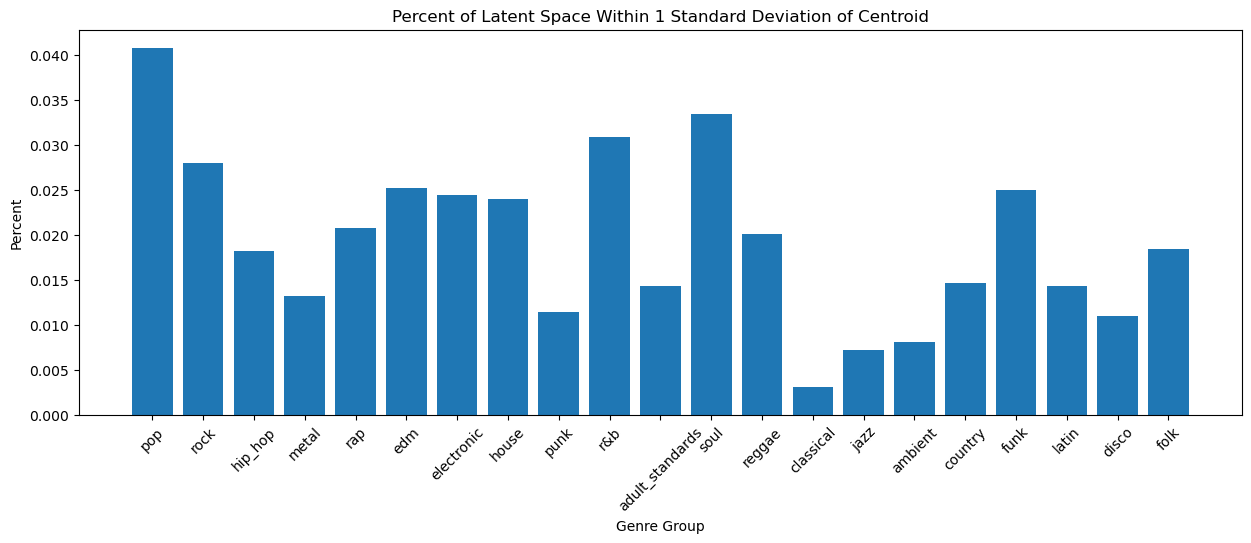

In [21]:
in_stds = []
#print the number of elements in the latents space that fall within 1 standard deviation of the centroid of each genre group
for i in range(len(centroids)):
    #get the centroid and standard deviation of the genre group
    centroid = centroids[i, 0, :]
    std = centroids[i, 1, :]
    #find the number of elements in the latent space that fall within 1 standard deviation of the centroid
    in_std = np.sum(np.sum(np.abs(latent_space - centroid) < std, axis=1) == latent_dim)
    in_stds.append(in_std)


in_std_percents = np.array(in_stds) / latent_space.shape[0] 
#plot the percents
plt.figure(figsize=(15, 5))
plt.bar(genre_group_labels, in_std_percents)
plt.xticks(rotation=45)
plt.title('Percent of Latent Space Within 1 Standard Deviation of Centroid')
plt.xlabel('Genre Group')
plt.ylabel('Percent')
plt.show()



### Generating Users

In [22]:
def create_users(num_users = 3, randomness_percent = 0.1, centroid_radius = 1, random_radius = None):
    #create a list will all possible combinations for the genre groups in the exercise, relax, and commute categories
    combinations = list(itertools.product(exercise_genres, relax_genres, commute_genres))

    #create an empty dataframe to store the user data
    users_df = pd.DataFrame()
    for user in range(num_users):
        #get a random combination of genre groups and remove it from the list of combinations
        exercise_genre, relax_genre, commute_genre = combinations.pop(np.random.randint(len(combinations)))

        #get all of the songs in the latent space that are 1 standard deviation away from the centroid of the exercise genre
        exercise_centroid = exercise_centroids[exercise_genres.index(exercise_genre), 0, :]
        exercise_std = exercise_centroids[exercise_genres.index(exercise_genre), 1, :]
        exercise_index = np.where(np.sum(np.abs(latent_space - exercise_centroid) < exercise_std*centroid_radius, axis=1) == latent_dim)[0]

        #get all of the songs in the latent space that are 1 standard deviation away from the centroid of the relax genre
        relax_centroid = relax_centroids[relax_genres.index(relax_genre), 0, :]
        relax_std = relax_centroids[relax_genres.index(relax_genre), 1, :]
        relax_index = np.where(np.sum(np.abs(latent_space - relax_centroid) < relax_std*centroid_radius, axis=1) == latent_dim)[0]

        #get all of the songs in the latent space that are 1 standard deviation away from the centroid of the commute genre
        commute_centroid = commute_centroids[commute_genres.index(commute_genre), 0, :]
        commute_std = commute_centroids[commute_genres.index(commute_genre), 1, :]
        commute_index = np.where(np.sum(np.abs(latent_space - commute_centroid) < commute_std*centroid_radius, axis=1) == latent_dim)[0]

        #convert the latent space to a dataframe
        user_df = pd.DataFrame(latent_space)
        user_df['user'] = user
        user_df['exercise'] = 0
        user_df['relax'] = 0
        user_df['commute'] = 0
        
        #set the exercise column to 1 for all of the songs in the exercise genre
        user_df.loc[exercise_index, 'exercise'] = 1
        #set the relax column to 1 for all of the songs in the relax genre
        user_df.loc[relax_index, 'relax'] = 1
        #set the commute column to 1 for all of the songs in the commute genre
        user_df.loc[commute_index, 'commute'] = 1

        #dict to store activity centroids and standard deviations
        activity_centroids = {'exercise': exercise_centroid, 'relax': relax_centroid, 'commute': commute_centroid}
        activity_stds = {'exercise': exercise_std, 'relax': relax_std, 'commute': commute_std}

        #add some randomness to the data
        #randomly select a percentage of the songs in each genre and switch the activity column
        for activity in ['exercise', 'relax', 'commute']:
            #get the index of the songs in the genre
            genre_index = user_df[user_df[activity] == 1].index
            not_genre_index = user_df[user_df[activity] == 0].index

            if random_radius:
                #get the index of the songs in the latent space that are within the random radius of the centroid
                random_index = np.where(np.sum(np.abs(latent_space - activity_centroids[activity]) < activity_stds[activity]*random_radius, axis=1) == latent_dim)[0]
                #get the index of the songs that are in the genre and within the random radius
                not_genre_index = np.intersect1d(not_genre_index, random_index)


            #get the number of songs to switch
            num_switch = int(len(genre_index) * randomness_percent)
            #get the index of the songs to switch


            switch_index_off = np.random.choice(genre_index, num_switch, replace=False)
            switch_index_on = np.random.choice(not_genre_index, num_switch, replace=False)
            #switch the activity column
            user_df.loc[switch_index_off, activity] = 0
            user_df.loc[switch_index_on, activity] = 1
            #switch the activity column for the other two activities

        #add the user dataframe to the overall dataframe
        if user == 0:
            users_df = user_df
        else:
            users_df = pd.concat([users_df, user_df], axis=0)

    return users_df

In [23]:
users_data = create_users(num_users=3, randomness_percent=0.1, centroid_radius=1, random_radius=None)
users_data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,user,exercise,relax,commute
0,0.306826,-0.770038,-0.382733,-0.789622,-0.637516,0.816120,0.671193,-1.193909,0.137937,-0.199856,-0.178573,0.084342,0,0,0,0
1,0.252397,2.181939,-1.158305,0.404378,-1.435527,1.232860,0.043267,3.661533,-0.856132,0.590296,-0.532474,1.998194,0,0,0,0
2,-0.399935,0.706309,0.220381,0.775744,0.118900,0.938098,-1.973868,-0.183656,0.514467,0.244139,-1.785830,0.639727,0,0,0,0
3,2.044566,2.610923,-1.473404,-0.793080,-2.416543,-0.694298,1.384062,6.121675,-0.219981,0.775259,2.088196,1.723756,0,0,0,0
4,1.594063,0.817521,-0.287690,-1.464800,-1.288823,0.484788,0.326023,0.529396,0.720782,0.776448,-1.496886,0.119744,0,0,0,0


In [24]:
#print the percent of songs with a 0 for all three activity columns per user
for user in users_data['user'].unique():
    print('User {} has {}% of songs with 0 for all three activity columns'.format(user, round(np.sum((users_data['user'] == user) 
                                                                                                     & (users_data['exercise'] == 0) 
                                                                                                     & (users_data['relax'] == 0) 
                                                                                                     & (users_data['commute'] == 0)) 
                                                                                                     / len(users_data[users_data['user'] == user]) * 100, 2)))

User 0 has 93.72% of songs with 0 for all three activity columns
User 1 has 94.71% of songs with 0 for all three activity columns
User 2 has 94.83% of songs with 0 for all three activity columns


## Train-Test Split

When I split the data, I am stratifying by each task and each activity so that there is a propotiaonally equal amount of data for each user and activity in both the training and test sets. I think it is crucial that I am stratifying be user so the model is not biased towards the preferences of any one user. If a given user is over-represented in the training data, this bias is probable. I am also stratifying between activity so that the model can accurately predict preferences for each activity. If a given activity is over represented it is possible that the model will bias predictions towards this activity.

In [25]:
#train test split with validation set
X = users_data.drop(columns=['exercise', 'relax', 'commute'])
y = users_data[['user', 'exercise', 'relax', 'commute']]

# split the data into training and test sets with stratification over user, exercise, relax, and commute
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=users_data[['user', 'exercise', 'relax', 'commute']])

# print the shape of the resulting sets
print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

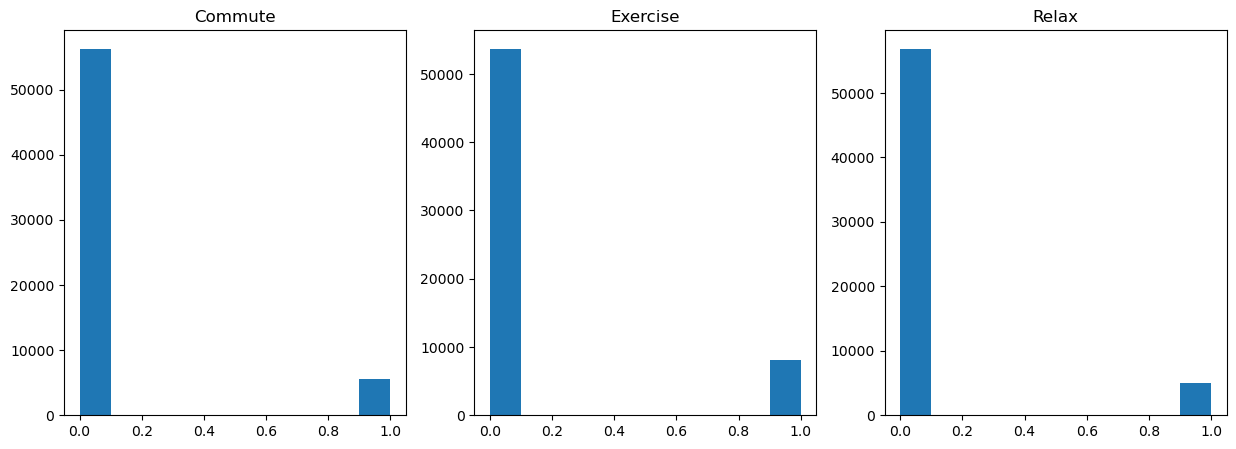

Commute:  0.08957686335403726
Exercise:  0.13122735507246377
Relax:  0.07995276915113872


In [ ]:
#checking for class imbalance with histograms
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(y_train['commute'])
ax[0].set_title('Commute')
ax[1].hist(y_train['exercise'])
ax[1].set_title('Exercise')
ax[2].hist(y_train['relax'])
ax[2].set_title('Relax')
plt.show()

#checking for class imbalance
print('Commute: ', np.sum(y_train['commute']) / len(y_train))
print('Exercise: ', np.sum(y_train['exercise']) / len(y_train))
print('Relax: ', np.sum(y_train['relax']) / len(y_train))


